In [32]:
import os
import pandas as pd
import numpy as np
from typing import Dict, List
import importlib
from pathlib import Path
import matplotlib.pyplot as plt
import MeCab
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from scipy.spatial import distance
import plotly.io as pio
import chart_studio
import chart_studio.plotly as py
import chart_studio.tools as tls
import seaborn as sns
import gc
import torch

In [33]:
# INFO: import local libraries
import python.data_manager as dm
import python.Mecab_processing as mp
import python.util as util

In [34]:
BASE_PATH = Path.cwd().parent
DATA_PATH = BASE_PATH / "data"
MODEL_PATH = BASE_PATH / "model"
FIG_PATH = BASE_PATH / "fig"
print(f"BASE_PATH: {BASE_PATH}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"MODEL_PATH: {MODEL_PATH}")

BASE_PATH: /home/masa1357/Dockerdata/gitfile/15-Encoders
DATA_PATH: /home/masa1357/Dockerdata/gitfile/15-Encoders/data
MODEL_PATH: /home/masa1357/Dockerdata/gitfile/15-Encoders/model


In [35]:
importlib.reload(util)
# ? logger読み込み
name = "15-Ensemble"
logger = util.set_logger()
# ? seed値固定
seed = 42
util.set_seed(seed)

2024-10-10 00:41:27,892 : python.util : INFO : 34 : Test_message


In [36]:
# ? データ読み込み
# import python.data_manager as dm

importlib.reload(dm)
# argsでloggerの名前を送る
args: Dict[str, object] = {
    "logger": logger,
    "DATA_PATH": DATA_PATH,
    "key": "userid",
    "text": "answer_content",
    "label": "grade",
    "mode": "all",
    "split_rate": [0.8, 0.2, 0],
    "seed": seed,
}

# with util.timer("load data"):
#     dp = dm.DataProcessing(args)
#     df= dp()

In [37]:
# def get_cosine_distance(data_dir):
#     df = pd.DataFrame()
#     for file in os.listdir(data_dir):
#         tmp = pd.DataFrame()
#         file_path = os.path.join(data_dir, file)
#         data = torch.load(file_path, weight_only=False, strict=False)
#         hidden_state_dict = data["hidden_states"]
#         for idx in range(hidden_state_dict.keys() - 2):
#             logger.info(f"get distance: {idx}:{idx+1}")
#             hidden_state_bef = hidden_state_dict[idx][-1]
#             hidden_state_aft = hidden_state_dict[idx + 1][-1]
#             hidden_state_bef_flat = hidden_state_bef.flatten()
#             hidden_state_aft_flat = hidden_state_aft.flatten()

#             # cos類似度を計算
#             # cos_distance = distance.cosine(hidden_state_bef, hidden_state_aft)
#             cos_similarity = torch.nn.functional.cosine_similarity(
#                 hidden_state_bef_flat, hidden_state_aft_flat, dim=0
#             )
#             cos_distance = 1 - cos_similarity
#             column_name = f"cos_{idx}:{idx+1}"
#             # dataframeに新しい列を追加
#             tmp[column_name] = [cos_distance]

#         # tmpの内容をdfの行として末尾に追加
#         df = pd.concat([df, tmp], axis=0)
#     return df

In [58]:
def get_cosine_distance(data_dir):
    df = pd.DataFrame()
    for file in os.listdir(data_dir):
        file_path = os.path.join(data_dir, file)
        data = torch.load(file_path, weights_only=False)
        hidden_state_dict = data["hidden_states"]
        label = data["label"]
        # labelがtensorの場合は、numpyに変換
        if isinstance(label, torch.Tensor):
            label = label.numpy()
        for idx in range(len(hidden_state_dict.keys()) - 1):
            # logger.info(f"get distance: {idx}:{idx+1}")
            hidden_state_bef = hidden_state_dict[idx][-1]
            hidden_state_aft = hidden_state_dict[idx + 1][-1]
            hidden_state_bef_flat = hidden_state_bef.flatten()
            hidden_state_aft_flat = hidden_state_aft.flatten()

            # コサイン類似度を計算
            cos_similarity = torch.nn.functional.cosine_similarity(
                hidden_state_bef_flat, hidden_state_aft_flat, dim=0
            )
            cos_distance = 1 - cos_similarity
            column_name = f"{idx+1}:{idx+2}"

            # 直接dfに新しい列を追加
            df.at[file, column_name] = cos_distance.item()
        #'15:16'列にコサイン類似度の平均値を追加
        df.at[file, "15:16"] = df.loc[file,].mean()
        df.at[file, "label"] = label

    return df

In [59]:
dir_path = "/home/masa1357/Dockerdata/gitfile/15-Encoders/src/log/15layers/hidden_states_normalmodel"
cos_df = get_cosine_distance(dir_path)

In [60]:
cos_df

,1:2,2:3,3:4,4:5,5:6,6:7,7:8,8:9,9:10,10:11,11:12,12:13,13:14,14:15,15:16,label
C-2022-1_U27.pt,0.241699,0.245117,0.245117,0.245117,0.222656,0.260254,0.248047,0.229004,0.223633,0.229492,0.249512,0.232422,0.247070,0.565918,0.263218,1.0
C-2021-2_U99.pt,0.183594,0.208984,0.203125,0.266602,0.302246,0.233398,0.200195,0.184570,0.229492,0.260742,0.241699,0.244141,0.251953,0.225586,0.231166,1.0
C-2021-1_U94.pt,0.162109,0.132812,0.106445,0.187012,0.206055,0.193359,0.200195,0.195801,0.175781,0.242188,0.225586,0.119629,0.121582,0.125977,0.171038,1.0
C-2022-1_U64.pt,0.330078,0.539551,0.547363,0.137695,0.135742,0.184570,0.413086,0.369141,0.114258,0.358398,0.349609,0.141602,0.102539,0.171387,0.278216,2.0
C-2021-2_U170.pt,0.266602,0.170898,0.144531,0.150391,0.168945,0.163574,0.139648,0.135742,0.187500,0.000000,0.000000,0.000000,0.000000,0.000000,0.109131,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C-2022-1_U8.pt,0.164062,0.186523,0.275391,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.044713,4.0
C-2021-2_U153.pt,0.166016,0.176758,0.143555,0.137207,0.153809,0.110352,0.192383,0.195801,0.161133,0.205078,0.194336,0.132324,0.137695,0.285156,0.170829,1.0
C-2022-1_U29.pt,0.254883,0.260742,0.246582,0.233887,0.294922,0.295410,0.246094,0.223633,0.229492,0.222656,0.238770,0.237793,0.221191,0.266602,0.248047,2.0
C-2021-1_U44.pt,0.152344,0.093750,0.095703,0.521484,0.366211,0.586914,0.457031,0.427734,0.488281,0.091797,0.165527,0.488281,0.393066,0.482422,0.343610,2.0


In [61]:
categories = {0: "A", 1: "B", 2: "C", 3: "D", 4: "F"}
cos_df["category"] = cos_df["label"].map(categories)
cos_df

,1:2,2:3,3:4,4:5,5:6,6:7,7:8,8:9,9:10,10:11,11:12,12:13,13:14,14:15,15:16,label,category
C-2022-1_U27.pt,0.241699,0.245117,0.245117,0.245117,0.222656,0.260254,0.248047,0.229004,0.223633,0.229492,0.249512,0.232422,0.247070,0.565918,0.263218,1.0,B
C-2021-2_U99.pt,0.183594,0.208984,0.203125,0.266602,0.302246,0.233398,0.200195,0.184570,0.229492,0.260742,0.241699,0.244141,0.251953,0.225586,0.231166,1.0,B
C-2021-1_U94.pt,0.162109,0.132812,0.106445,0.187012,0.206055,0.193359,0.200195,0.195801,0.175781,0.242188,0.225586,0.119629,0.121582,0.125977,0.171038,1.0,B
C-2022-1_U64.pt,0.330078,0.539551,0.547363,0.137695,0.135742,0.184570,0.413086,0.369141,0.114258,0.358398,0.349609,0.141602,0.102539,0.171387,0.278216,2.0,C
C-2021-2_U170.pt,0.266602,0.170898,0.144531,0.150391,0.168945,0.163574,0.139648,0.135742,0.187500,0.000000,0.000000,0.000000,0.000000,0.000000,0.109131,4.0,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C-2022-1_U8.pt,0.164062,0.186523,0.275391,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.044713,4.0,F
C-2021-2_U153.pt,0.166016,0.176758,0.143555,0.137207,0.153809,0.110352,0.192383,0.195801,0.161133,0.205078,0.194336,0.132324,0.137695,0.285156,0.170829,1.0,B
C-2022-1_U29.pt,0.254883,0.260742,0.246582,0.233887,0.294922,0.295410,0.246094,0.223633,0.229492,0.222656,0.238770,0.237793,0.221191,0.266602,0.248047,2.0,C
C-2021-1_U44.pt,0.152344,0.093750,0.095703,0.521484,0.366211,0.586914,0.457031,0.427734,0.488281,0.091797,0.165527,0.488281,0.393066,0.482422,0.343610,2.0,C


In [62]:
# INFO: グラフを2行4列で表示
def boxplotter(df, filename=None):
    fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(20, 30), sharey=True)
    axes = axes.flatten()  # 2次元配列を1次元配列に変換
    for i in range(1, 16):
        name = f"{i}:{i+1}"
        df.boxplot(
            column=name,
            ax=axes[i - 1],
            by="category",
            grid=False,
            showfliers=True,
            color="black",
        )

        axes[i - 1].set_title(name)
        if i == 15:
            axes[i - 1].set_title("mean")
        axes[i - 1].set_xlabel("Grade")
        # plt.xlabel("Grade")

    plt.suptitle("")
    plt.tight_layout()

    if filename is not None:
        plt.savefig(FIG_PATH / f"{filename}.svg")

    plt.show()

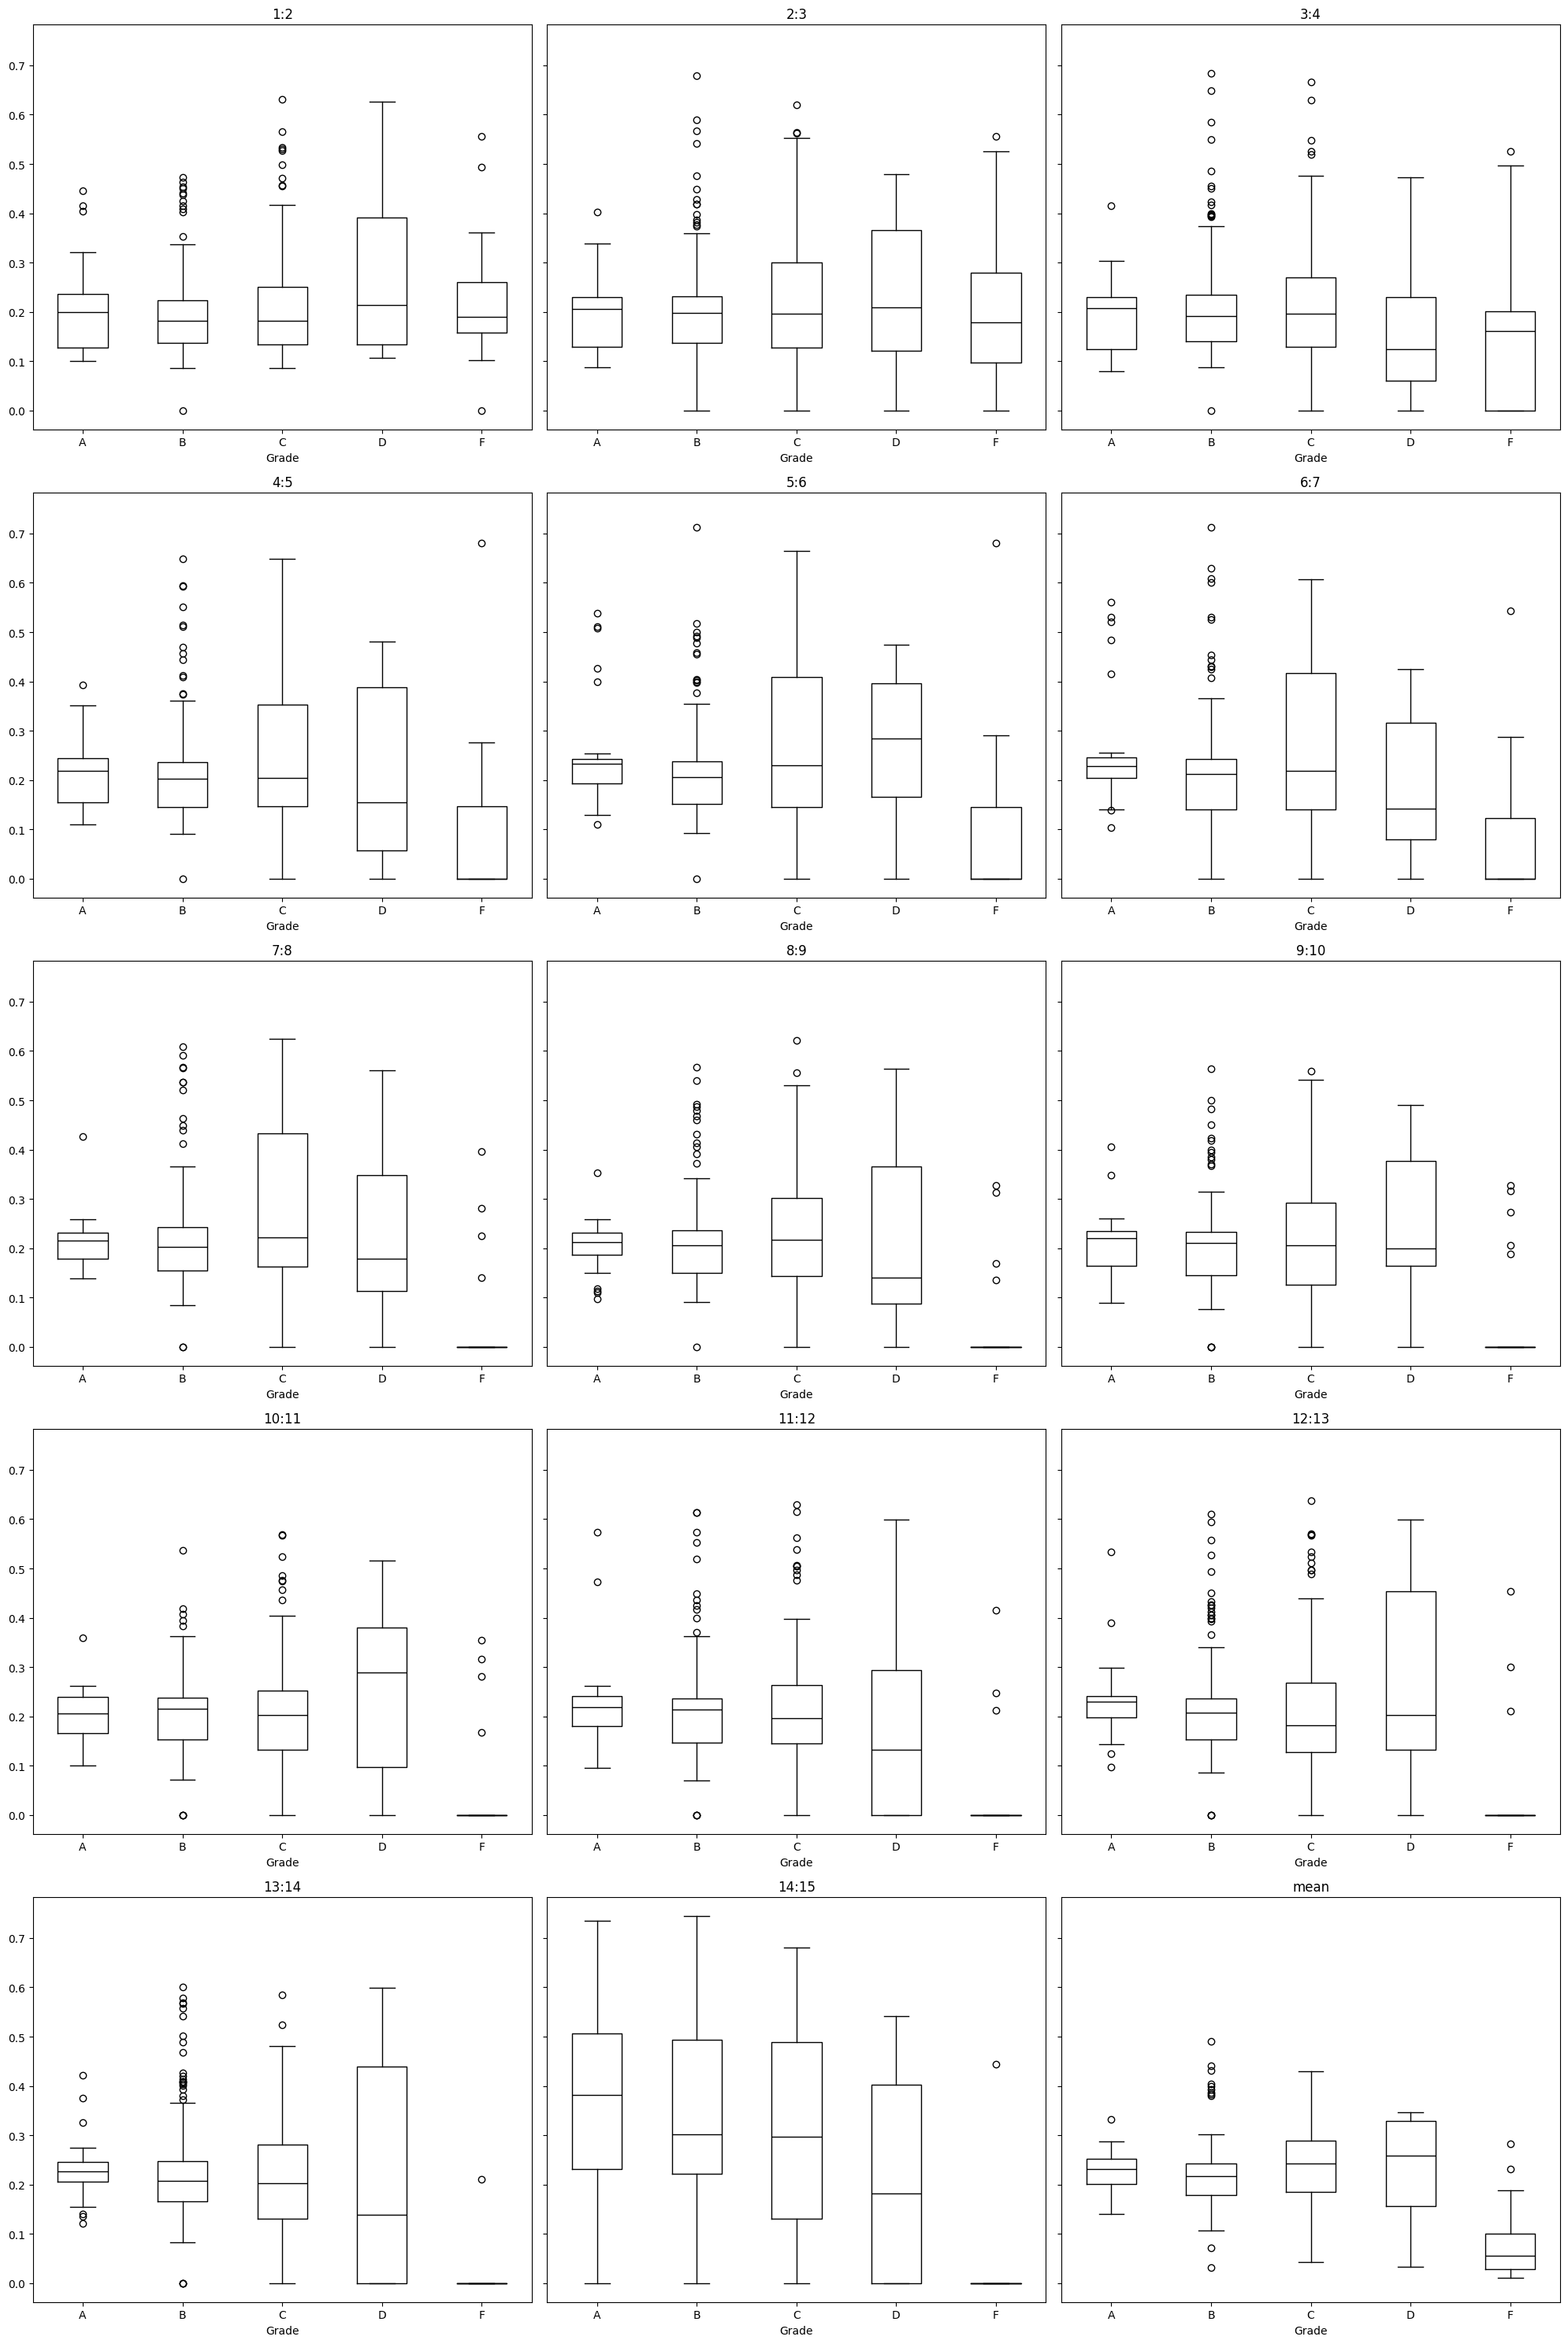

In [63]:
boxplotter(cos_df, filename="cosine_distance")
# clear